In [ ]:
# ==============================================================
# AEGIS-75 High Power Rocket Simulation
# Section 1 : Installation & Imports
# ==============================================================

!pip -q install rocketpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from rocketpy import Environment
from rocketpy import Rocket
from rocketpy import Flight
from rocketpy import SolidMotor

%matplotlib inline

print("RocketPy Installed Successfully")
# ==============================================================
# Create Custom Drag Curves
# ==============================================================

power_off_drag = """0.00,0.320
0.10,0.318
0.20,0.315
0.30,0.312
0.40,0.308
0.50,0.305
0.60,0.304
0.70,0.310
0.80,0.345
0.85,0.390
0.90,0.445
0.95,0.520
1.00,0.590
1.05,0.620
1.10,0.630
1.20,0.610
1.30,0.580
1.40,0.550
1.50,0.520
1.60,0.500
1.80,0.470
2.00,0.445
2.20,0.430
2.50,0.410
3.00,0.390
"""

power_on_drag = """0.00,0.310
0.10,0.308
0.20,0.305
0.30,0.302
0.40,0.298
0.50,0.296
0.60,0.295
0.70,0.300
0.80,0.335
0.85,0.380
0.90,0.430
0.95,0.500
1.00,0.565
1.05,0.595
1.10,0.605
1.20,0.585
1.30,0.555
1.40,0.525
1.50,0.495
1.60,0.475
1.80,0.445
2.00,0.420
2.20,0.405
2.50,0.390
3.00,0.370
"""

with open("powerOffDragCurve.csv","w") as f:
    f.write(power_off_drag)

with open("powerOnDragCurve.csv","w") as f:
    f.write(power_on_drag)

print("Drag curves created successfully.")
!wget -q https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/airfoils/NACA0012-radians.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.6/415.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 109.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 83.1 MB/s eta 0:00:00
RocketPy Installed Successfully
Drag curves created successfully.


Environment Created Successfully

Gravity Details

Acceleration of gravity at surface level:    9.7857 m/s²
Acceleration of gravity at  79.944 km (ASL): 9.5437 m/s²


Launch Site Details

Launch Date: 2026-06-30 12:00:00 UTC
Launch Site Latitude: 19.15025°
Launch Site Longitude: 73.23245°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 945383.64 E    2122855.81 N
Launch Site UTM zone: 42Q
Launch Site Surface Elevation: 72.6 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 79.944 km
Forecast Time Period: from 2026-06-22 00:00:00 to 2026-07-15 00:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From 90.0° to -90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 2.48 m/s
Surface Wind Direction: 202.73°
Surface Wind Heading: 22.73°
Surface Pressure: 99837.94 hPa
Surface Temperature: 298.13 K
Surface Air Density: 116.661 kg/m³
Surface Speed of Sound: 346.14 m/s


Earth Model

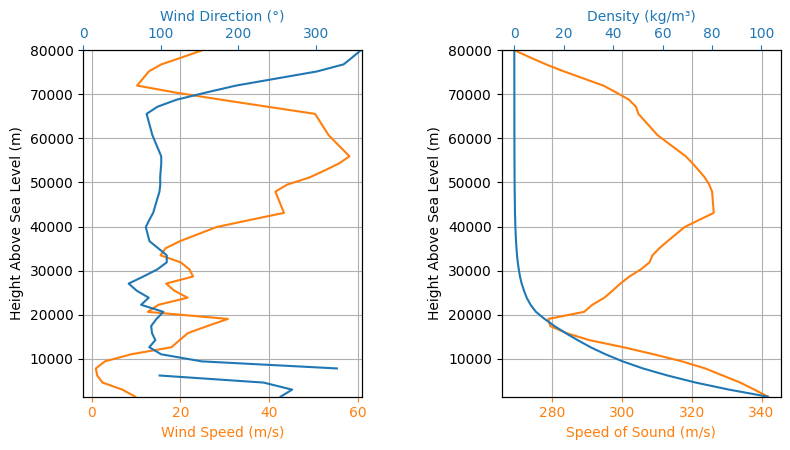

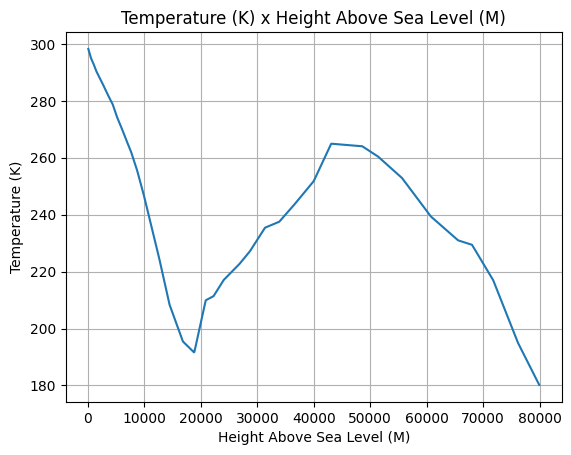

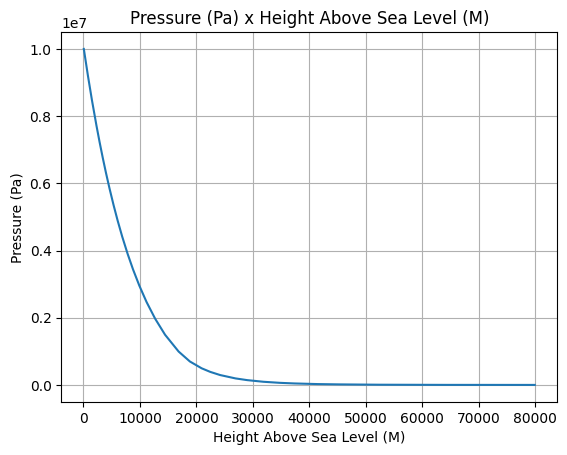

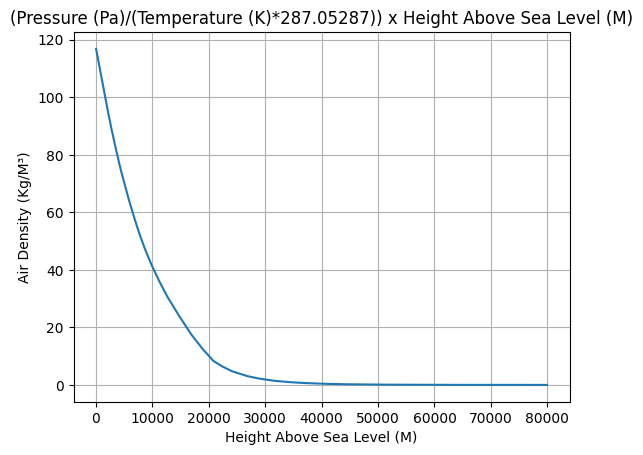

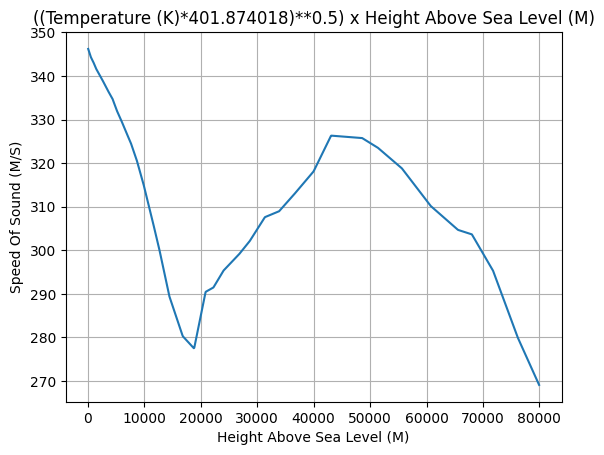

In [ ]:
# ==============================================================
# SECTION 2 : ENVIRONMENT
# ==============================================================

from rocketpy import Environment
import datetime

# --------------------------------------------------------------
# Launch Site
# --------------------------------------------------------------

env = Environment(
    latitude=19.150250,
    longitude=73.232450,
    elevation=1400
)

# --------------------------------------------------------------
# Launch Date
# --------------------------------------------------------------

tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env.set_date(
    (
        tomorrow.year,
        tomorrow.month,
        tomorrow.day,
        12,          # UTC
    )
)

# --------------------------------------------------------------
# Atmospheric Model
# --------------------------------------------------------------

env.set_atmospheric_model(
    type="Forecast",
    file="GFS"
)

print("Environment Created Successfully")
env.info()


env.temperature.plot()
env.pressure.plot()
env.density.plot()
env.speed_of_sound.plot()

Motor Created Successfully
Nozzle Details
Nozzle Radius: 0.0375 m
Nozzle Throat Radius: 0.011 m

Grain Details
Number of Grains: 5
Grain Spacing: 0.005 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.033 m
Grain Inner Radius: 0.015 m
Grain Height: 0.12 m
Grain Volume: 0.000 m3
Grain Mass: 0.591 kg

Motor Details
Total Burning Time: 4.01 s
Total Propellant Mass: 2.956 kg
Structural Mass Ratio: 0.393
Average Propellant Exhaust Velocity: 2278.410 m/s
Average Thrust: 1679.496 N
Maximum Thrust: 2411.0 N at 0.1 s after ignition.
Total Impulse: 6734.779 Ns



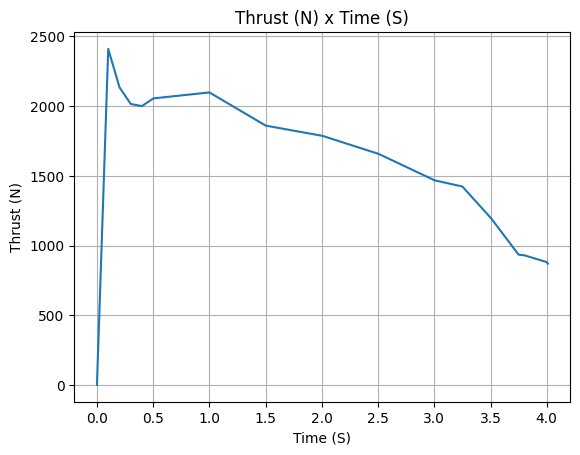

In [ ]:
# ==============================================================
# SECTION 3 : MOTOR
# AeroTech M1850W
# ==============================================================

from rocketpy import SolidMotor

M1850W = SolidMotor(

    thrust_source="AeroTech_M1850W.rse",

    dry_mass=1.910,

    dry_inertia=(0.060, 0.060, 0.002),

    nozzle_radius=0.0375,

    throat_radius=0.011,

    grain_number=5,

    grain_density=1815,

    grain_outer_radius=0.033,

    grain_initial_inner_radius=0.015,

    grain_initial_height=0.120,

    grain_separation=0.005,

    grains_center_of_mass_position=0.397,

    center_of_dry_mass_position=0.317,

    nozzle_position=0,

    burn_time=4.01,

    coordinate_system_orientation="nozzle_to_combustion_chamber"

)

print("Motor Created Successfully")
M1850W.info()

Rocket Created Successfully

Inertia Details

Rocket Mass: 18.000 kg (without motor)
Rocket Dry Mass: 19.910 kg (with unloaded motor)
Rocket Loaded Mass: 22.866 kg
Rocket Structural Mass Ratio: 0.871
Rocket Inertia (with unloaded motor) 11: 13.563 kg*m2
Rocket Inertia (with unloaded motor) 22: 13.563 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.092 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0375 m
Rocket Frontal Area: 0.004418 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.090 m
Rocket Center of Dry Mass - Nozzle Exit: 1.160 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.763 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.099 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 21.3

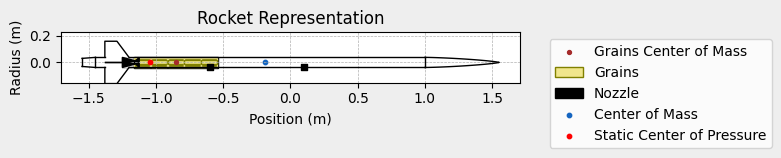


Mass Plots
----------------------------------------


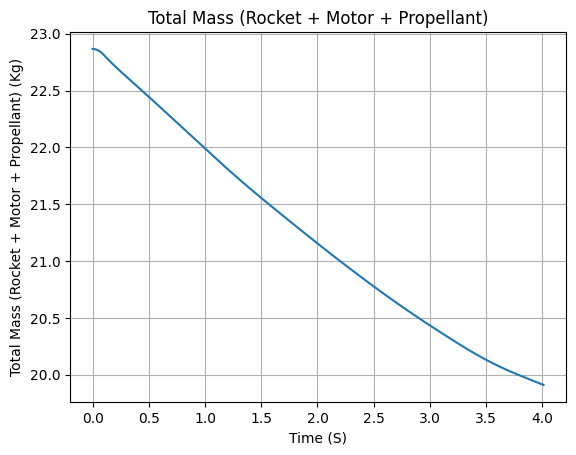

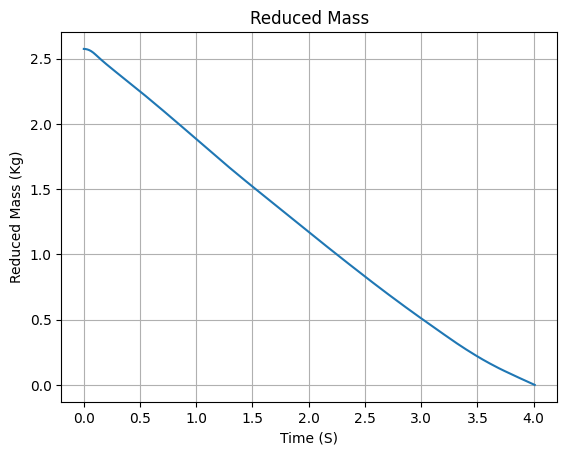


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


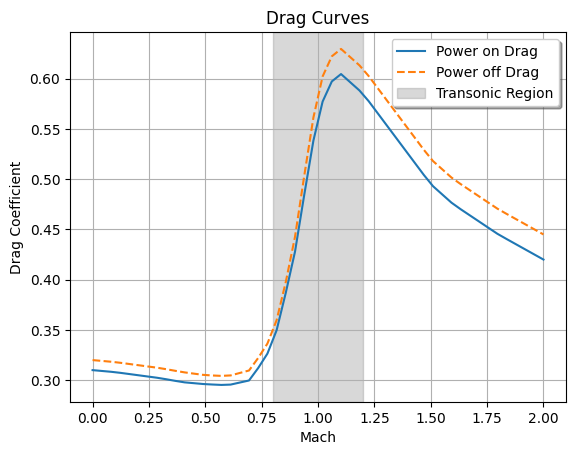


Stability Plots
--------------------


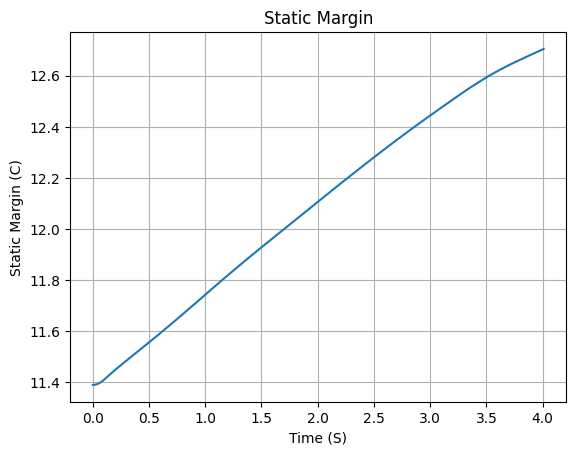

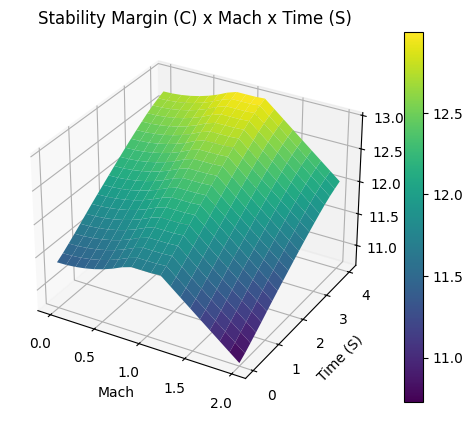


Thrust-to-Weight Plot
----------------------------------------


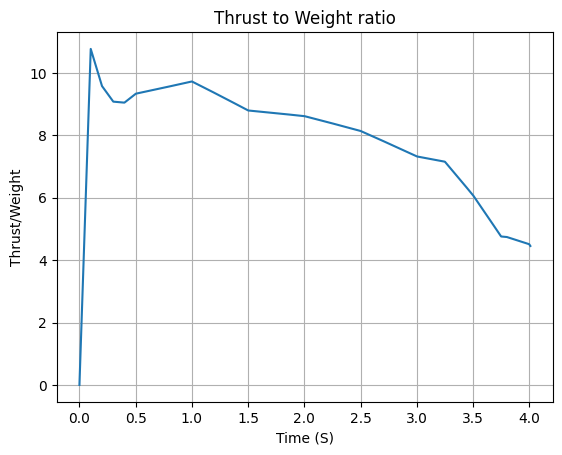

In [ ]:
# ==============================================================
# SECTION 4 : AEGIS-75 ROCKET
# ==============================================================

from rocketpy import Rocket

rocket = Rocket(

    radius=0.0375,                 # 75 mm diameter

    mass=18.0,                     # Empty rocket mass (kg)

    inertia=(12.0, 12.0, 0.09),

    power_off_drag="powerOffDragCurve.csv",

    power_on_drag="powerOnDragCurve.csv",

    center_of_mass_without_motor=0.0,

    coordinate_system_orientation="tail_to_nose"

)

print("Rocket Created Successfully")
rocket.set_rail_buttons(

    upper_button_position=0.10,

    lower_button_position=-0.60,

    angular_position=45

)
rocket.add_motor(

    M1850W,

    position=-1.25

)
rocket.add_nose(

    length=0.55,

    kind="vonKarman",

    position=1.55

)
rocket.add_trapezoidal_fins(

    n=4,

    root_chord=0.18,

    tip_chord=0.09,

    span=0.12,

    position=-1.20,

    cant_angle=0.0,

    airfoil=("NACA0012-radians.txt","radians")

)
rocket.add_tail(

    top_radius=0.0375,

    bottom_radius=0.030,

    length=0.10,

    position=-1.45

)
rocket.add_parachute(

    "Drogue",

    cd_s=1.0,

    trigger="apogee",

    sampling_rate=100,

    lag=1.5,

    noise=(0,8.3,0.5)

)
rocket.add_parachute(

    "Main",

    cd_s=8.5,

    trigger=500,

    sampling_rate=100,

    lag=1.5,

    noise=(0,8.3,0.5)

)
rocket.all_info()

Flight Simulation Created Successfully

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 72.56 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.923 | e1: -0.040 | e2: 0.017 | e3: 0.382
Euler Angles - Spin φ : 45.00° | Nutation θ: -5.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 11.389 c


Surface Wind Conditions

Frontal Surface Wind Speed: 2.29 m/s
Lateral Surface Wind Speed: -0.96 m/s


Launch Rail

Launch Rail Length: 6.0 m
Launch Rail Inclination: 85.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.377 s
Rail Departure Velocity: 27.360 m/s
Rail Departure Stability Margin: 11.514 c
Rail Departure Angle of Attack: 5.316°
Rail Departure Thrust-Weight Ratio: 9.058
Rail Departure Reynolds Number: 1.298e+07


Burn out State

Burn out time: 4.010 s
Altitude at burn out: 457.965 m (ASL) | 385.405 m (AGL)
Rocket speed at 

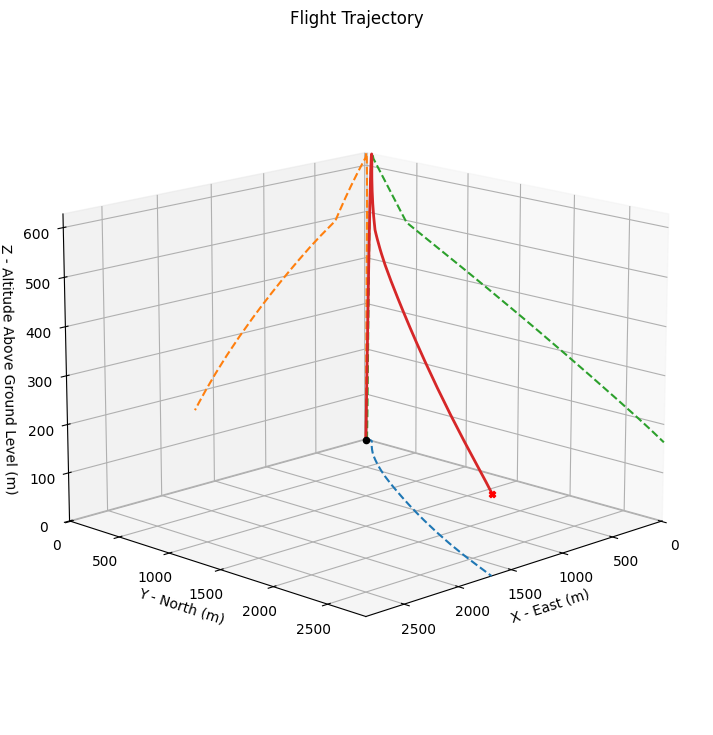



Trajectory Kinematic Plots



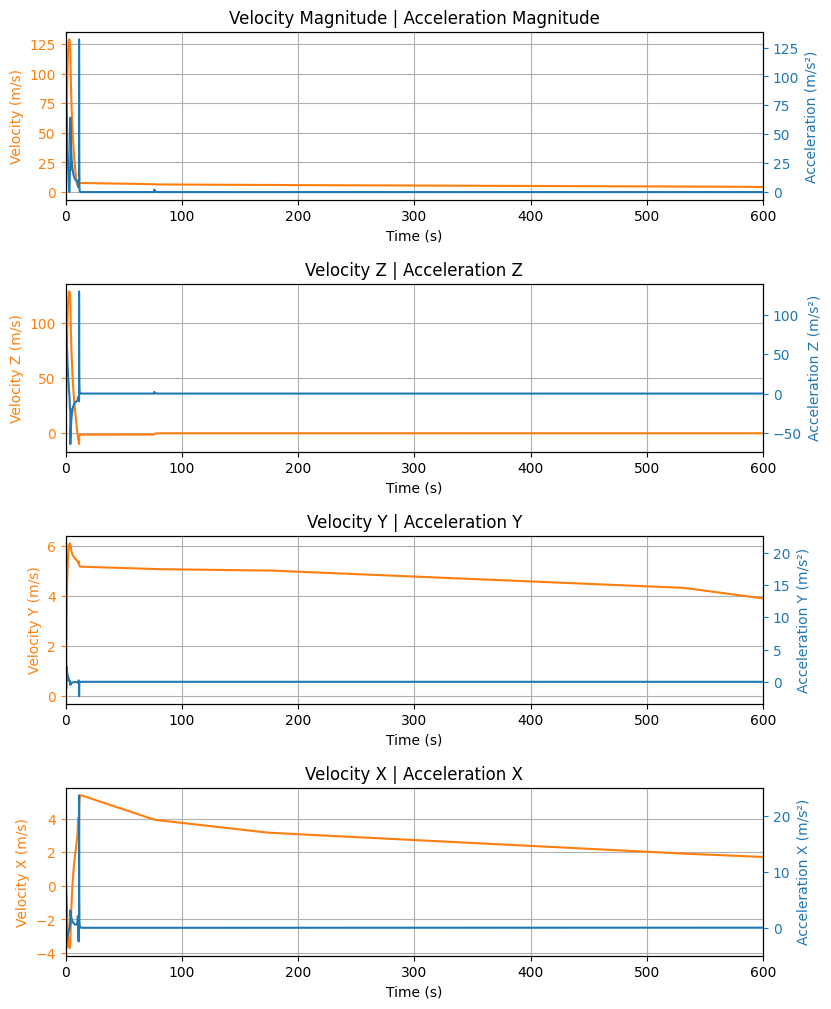



Angular Position Plots



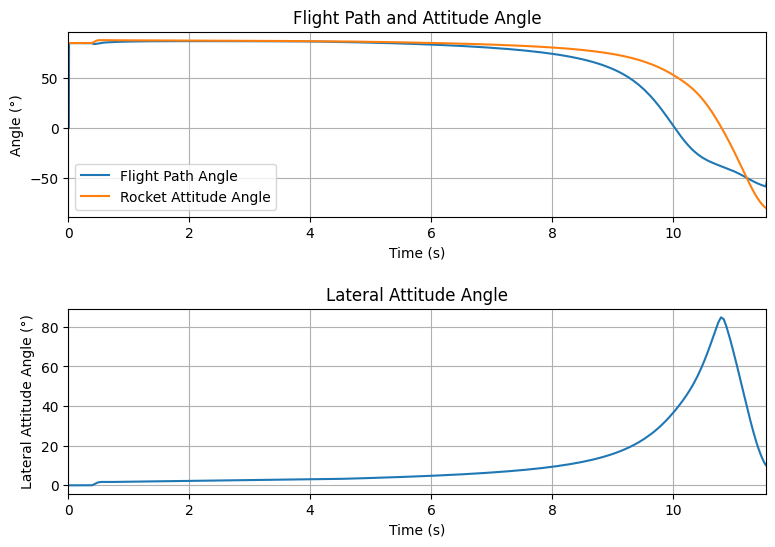



Path, Attitude and Lateral Attitude Angle plots



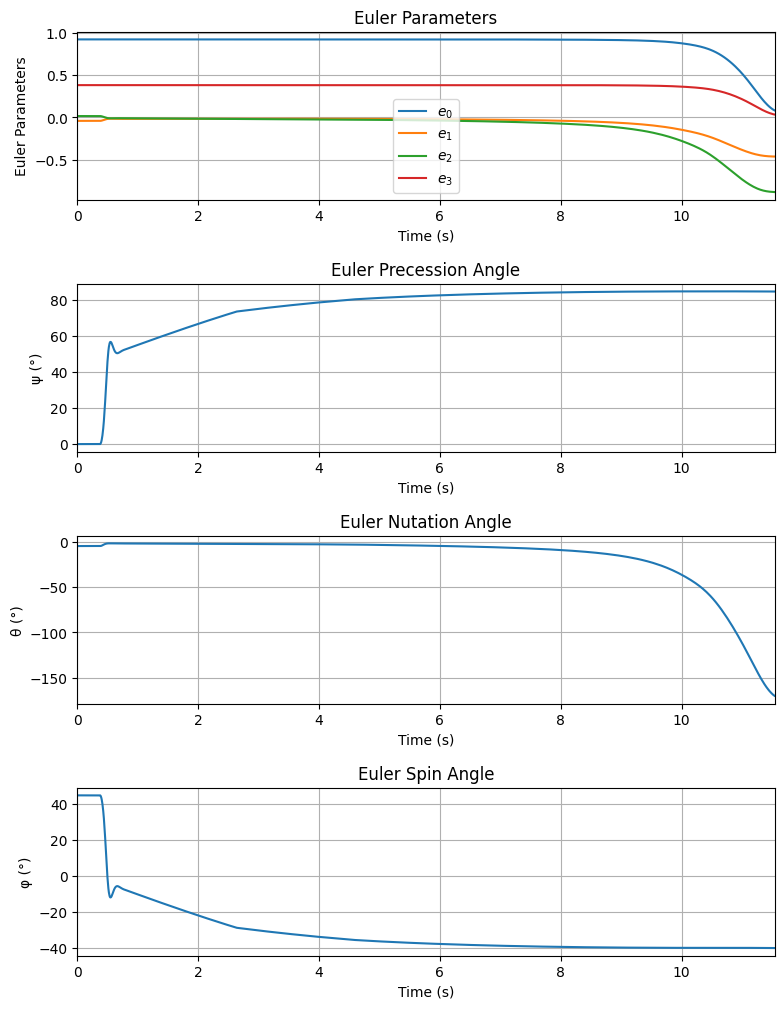



Trajectory Angular Velocity and Acceleration Plots



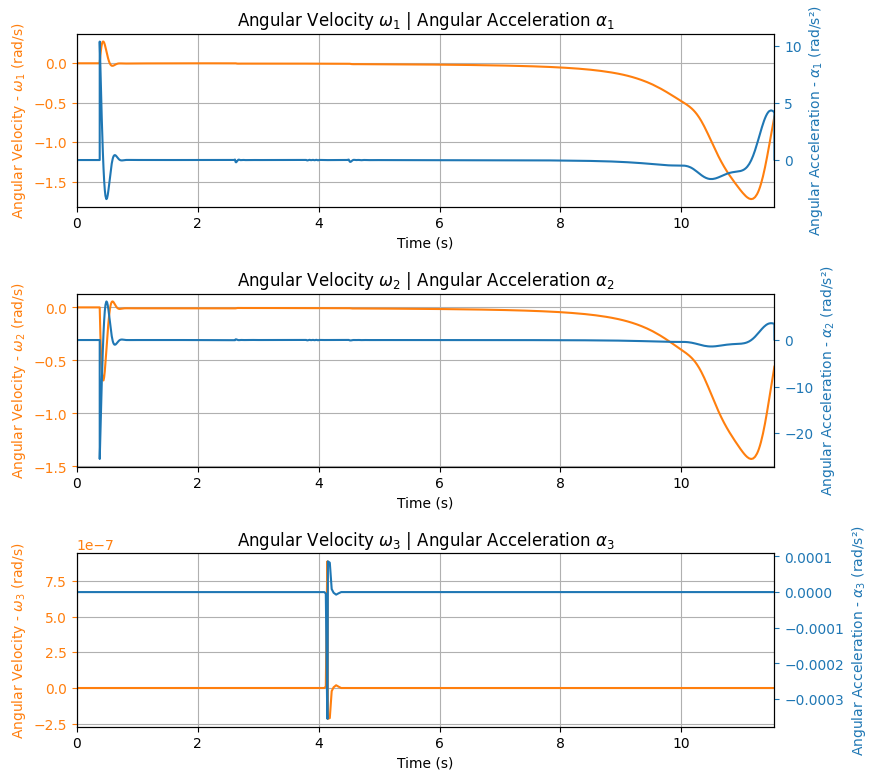



Aerodynamic Forces Plots



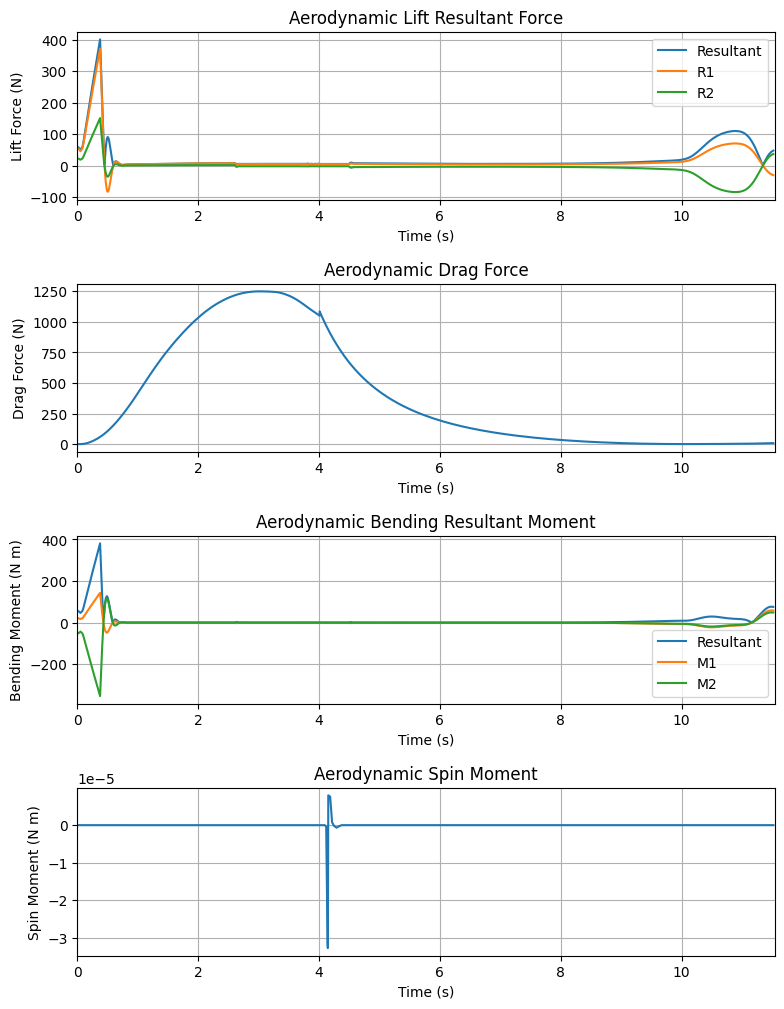



Rail Buttons Bending Moments Plots

Rail button height not defined. Skipping bending moment plots.


Rail Buttons Forces Plots



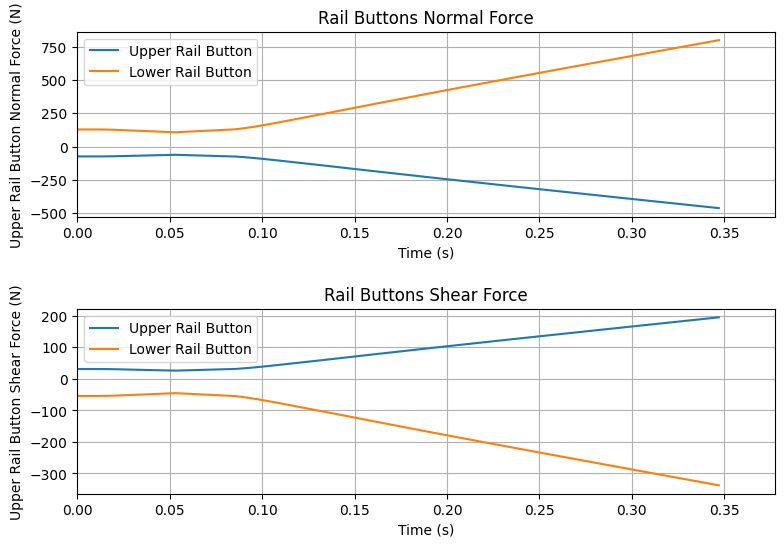



Trajectory Energy Plots



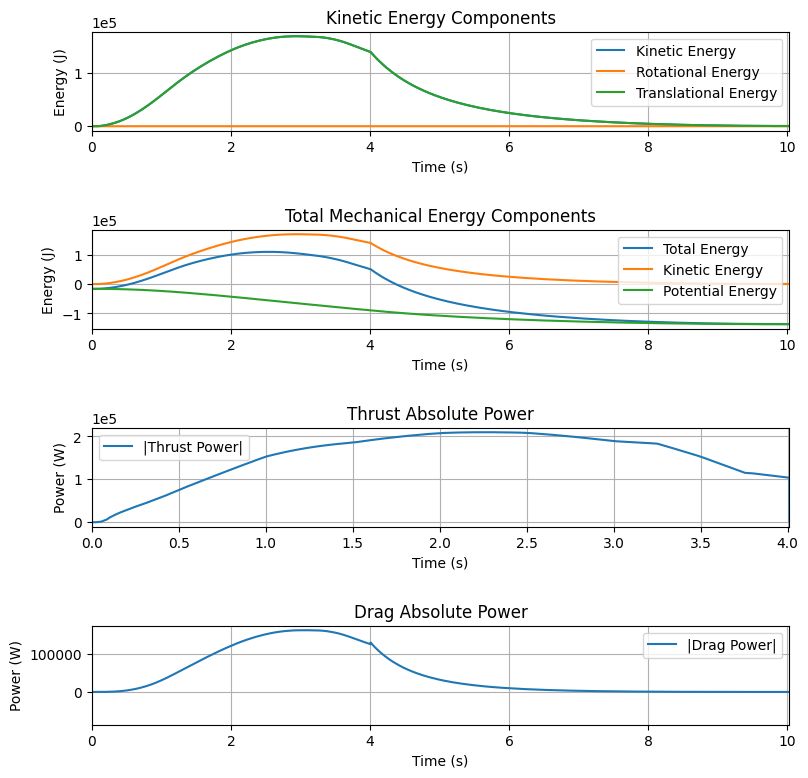



Trajectory Fluid Mechanics Plots



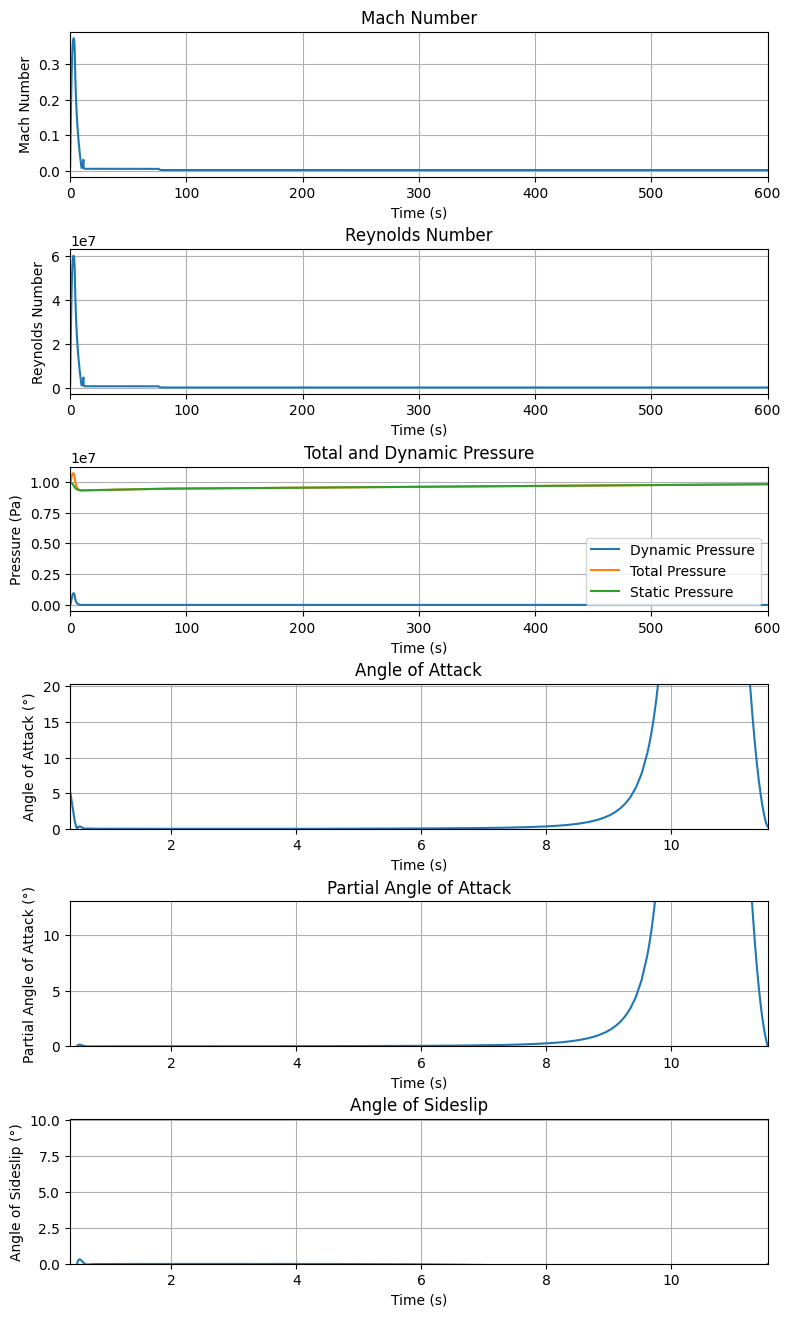



Trajectory Stability and Control Plots



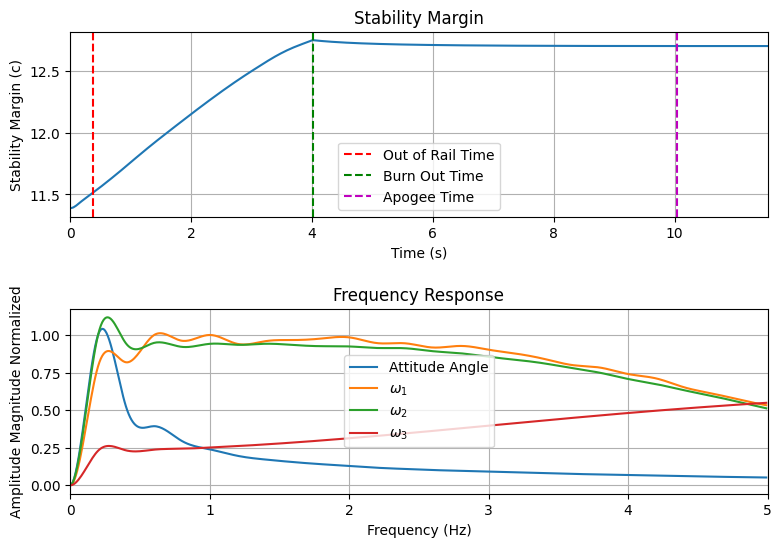



Rocket and Parachute Pressure Plots



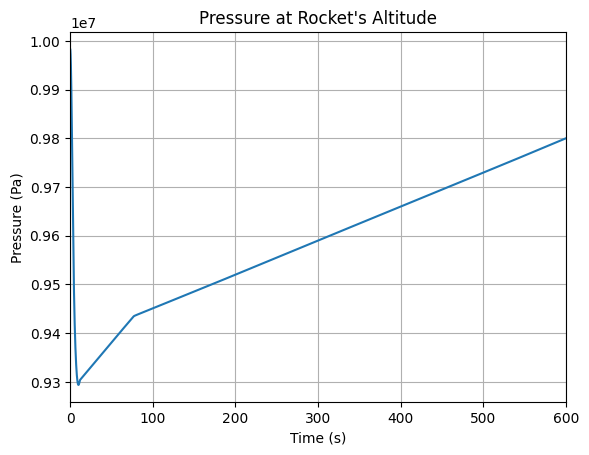


Parachute:  Drogue


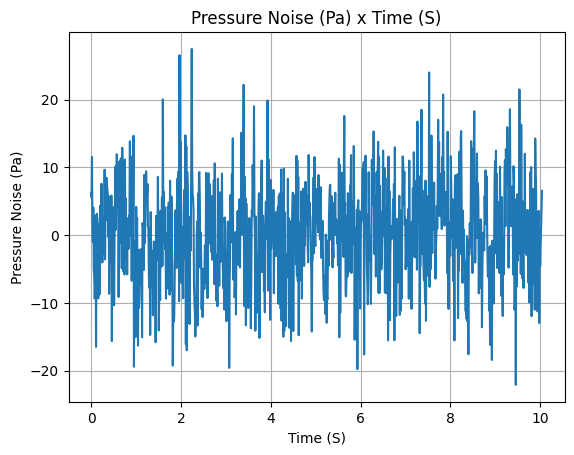

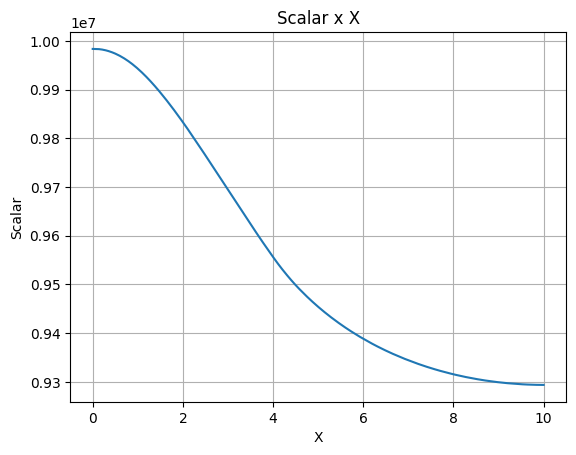

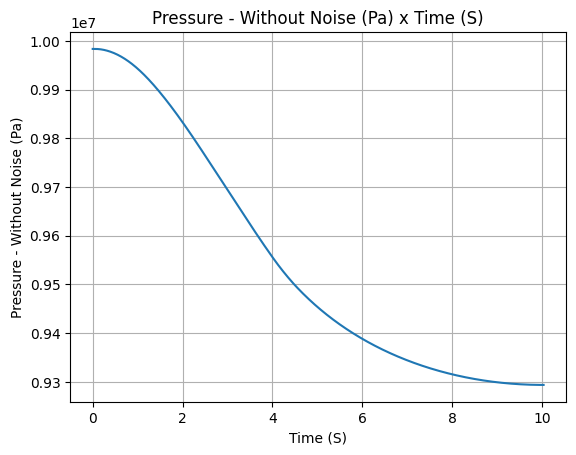


Parachute:  Main


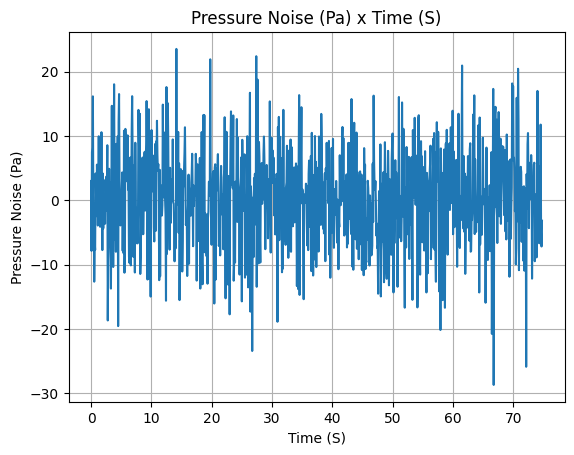

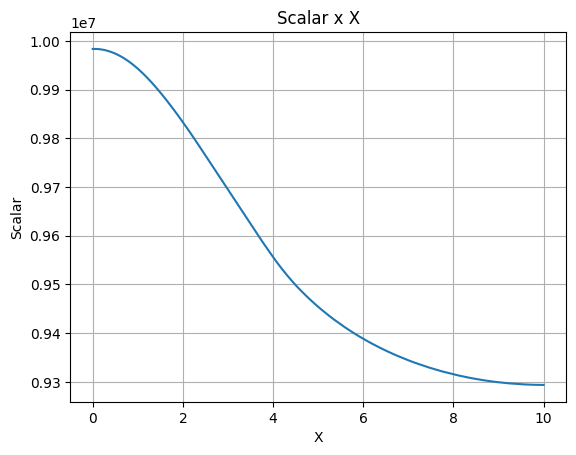

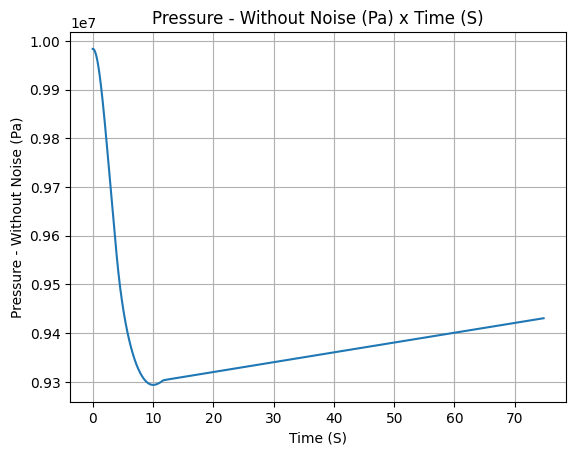

File  Aegis75_Trajectory.kml  saved with success!
Trajectory exported.
        AEGIS-75 FLIGHT SUMMARY
Apogee              : 699.83 m
Flight Time         : 600.00 s
Maximum Speed       : 128.90 m/s
Maximum Acceleration: 132.07 m/s²
Rail Exit Speed     : 27.36 m/s


/tmp/ipykernel_1330/2314242030.py:21: DeprecationWarning: Moved to FlightDataExporter.export_kml() and will be removed in v1.12.0. Use `rocketpy.simulation.flight_data_exporter.FlightDataExporter.export_kml` instead.
  flight.export_kml(


In [ ]:
# ==============================================================
# SECTION 5 : FLIGHT SIMULATION
# ==============================================================

flight = Flight(

    rocket=rocket,

    environment=env,

    rail_length=6.0,

    inclination=85,

    heading=0

)

print("Flight Simulation Created Successfully")
flight.all_info()
flight.export_kml(

    file_name="Aegis75_Trajectory.kml",

    extrude=True,

    altitude_mode="relative_to_ground"

)

print("Trajectory exported.")
print("="*50)
print("        AEGIS-75 FLIGHT SUMMARY")
print("="*50)

print(f"Apogee              : {flight.apogee:.2f} m")
print(f"Flight Time         : {flight.t_final:.2f} s")
print(f"Maximum Speed       : {flight.max_speed:.2f} m/s")

print(f"Maximum Acceleration: {flight.max_acceleration:.2f} m/s²")
print(f"Rail Exit Speed     : {flight.out_of_rail_velocity:.2f} m/s")



Trajectory 3d Plot



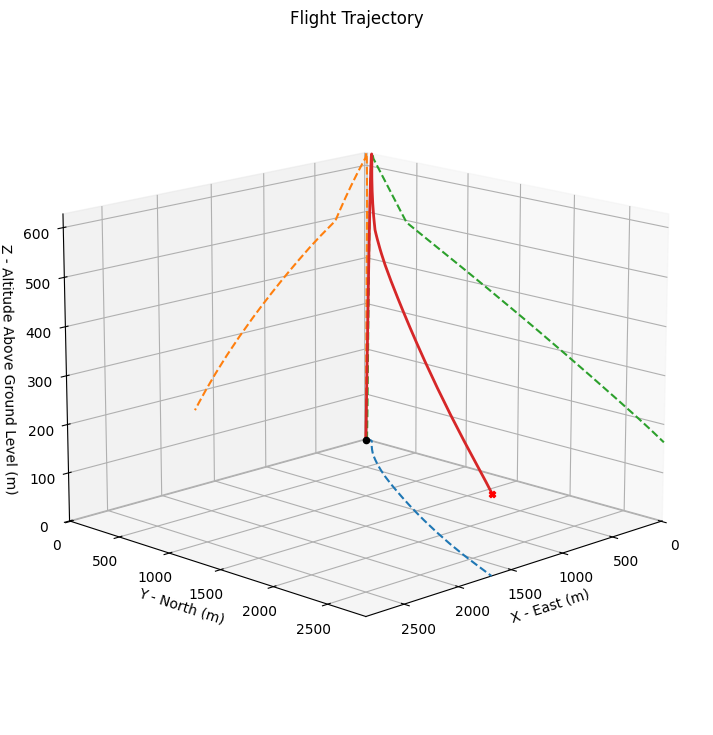



Trajectory Kinematic Plots



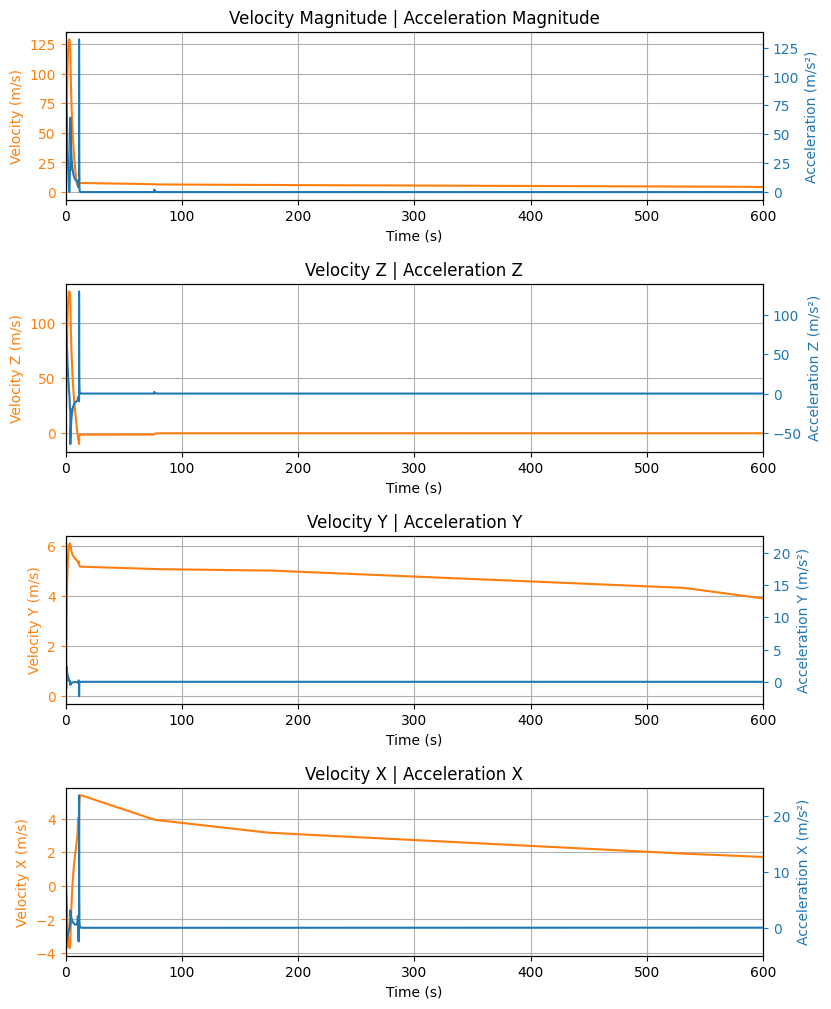



Angular Position Plots



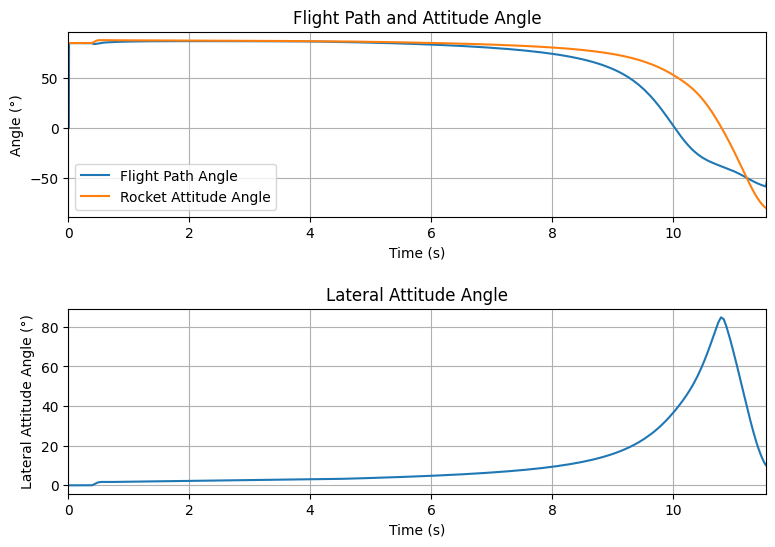



Path, Attitude and Lateral Attitude Angle plots



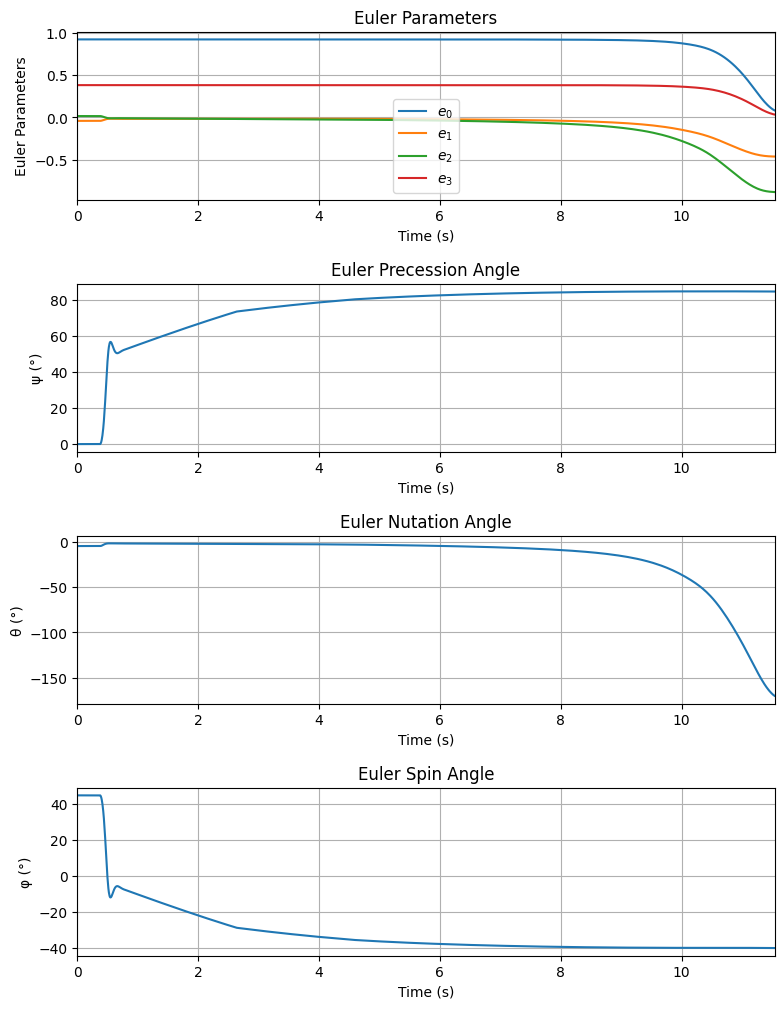



Trajectory Angular Velocity and Acceleration Plots



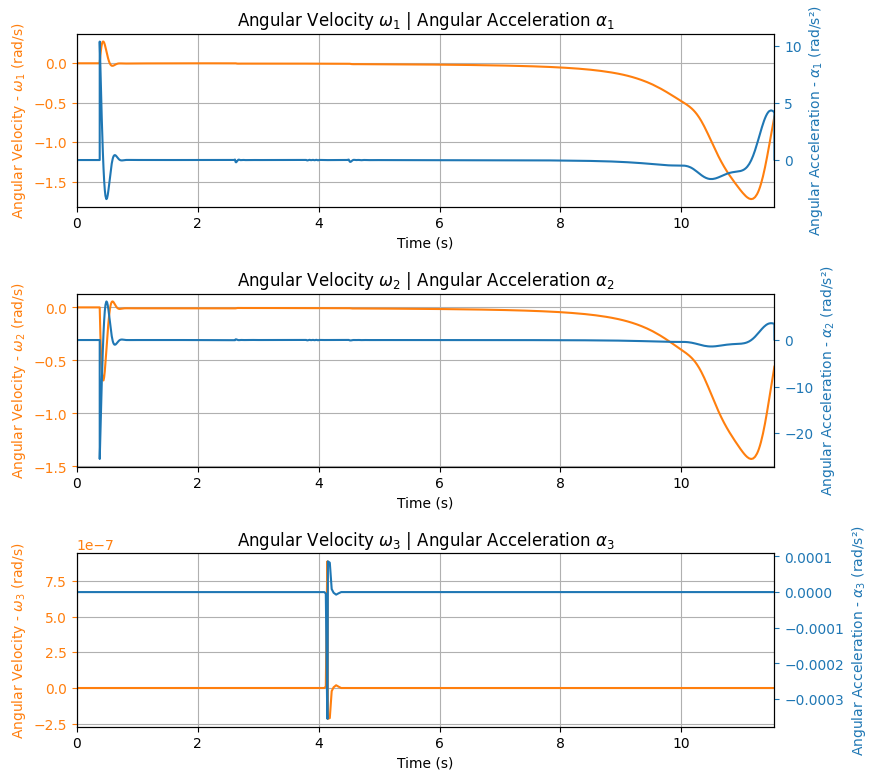



Aerodynamic Forces Plots



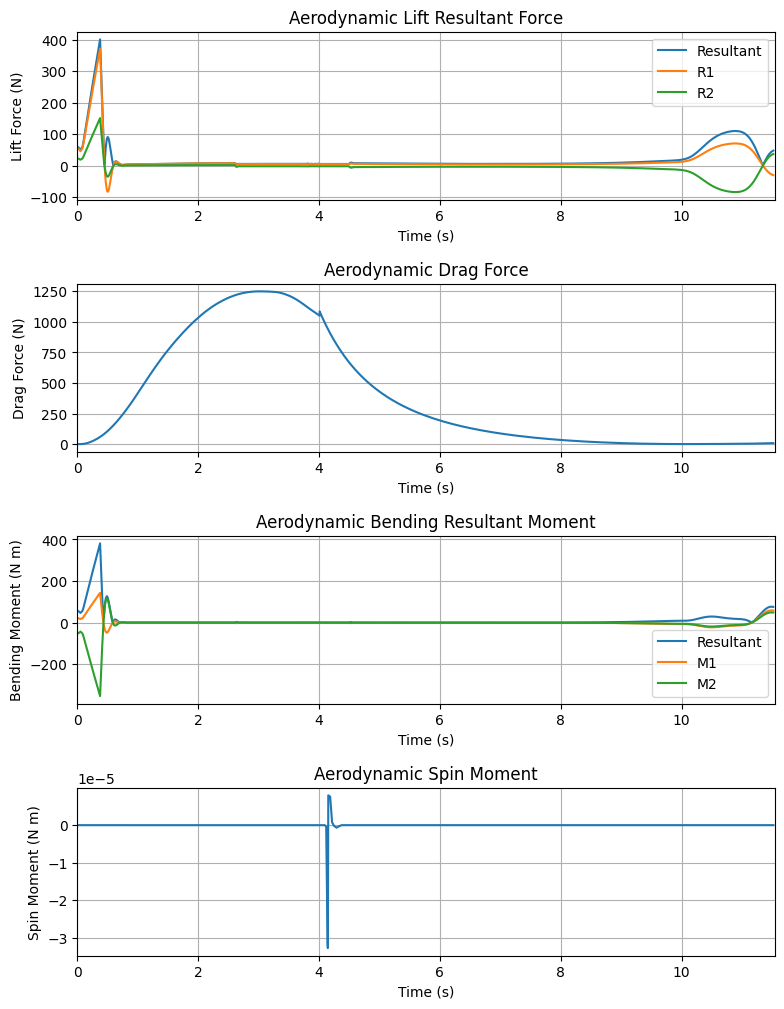



Rail Buttons Bending Moments Plots

Rail button height not defined. Skipping bending moment plots.


Rail Buttons Forces Plots



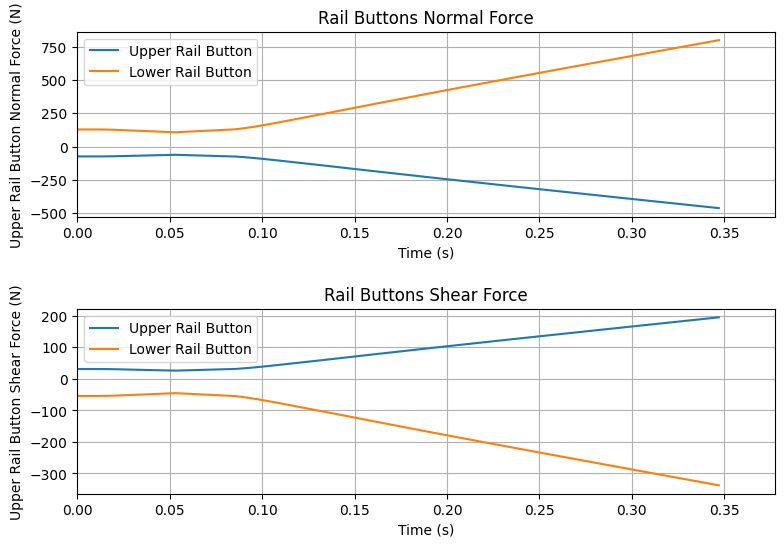



Trajectory Energy Plots



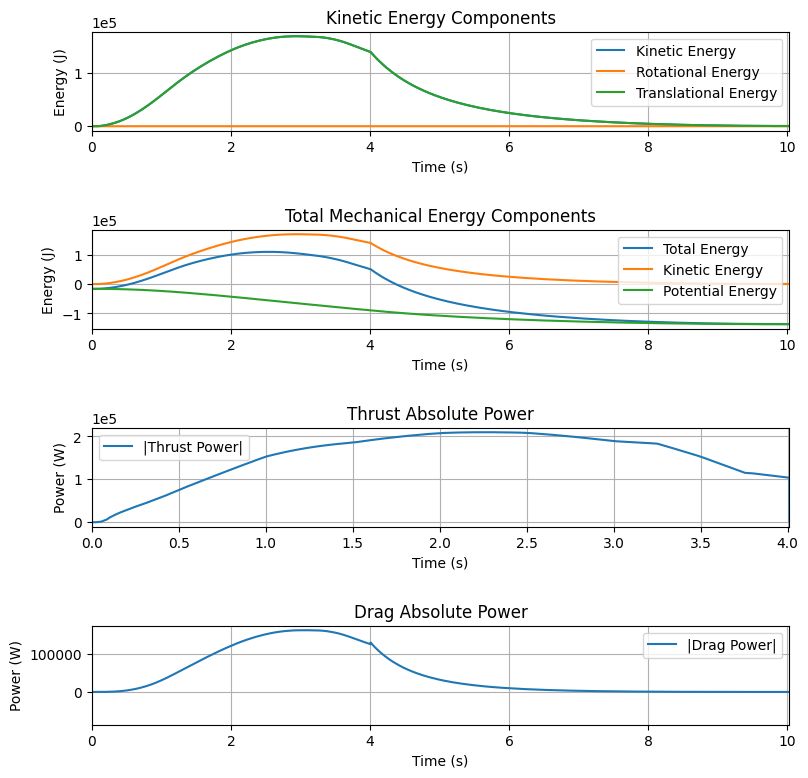



Trajectory Fluid Mechanics Plots



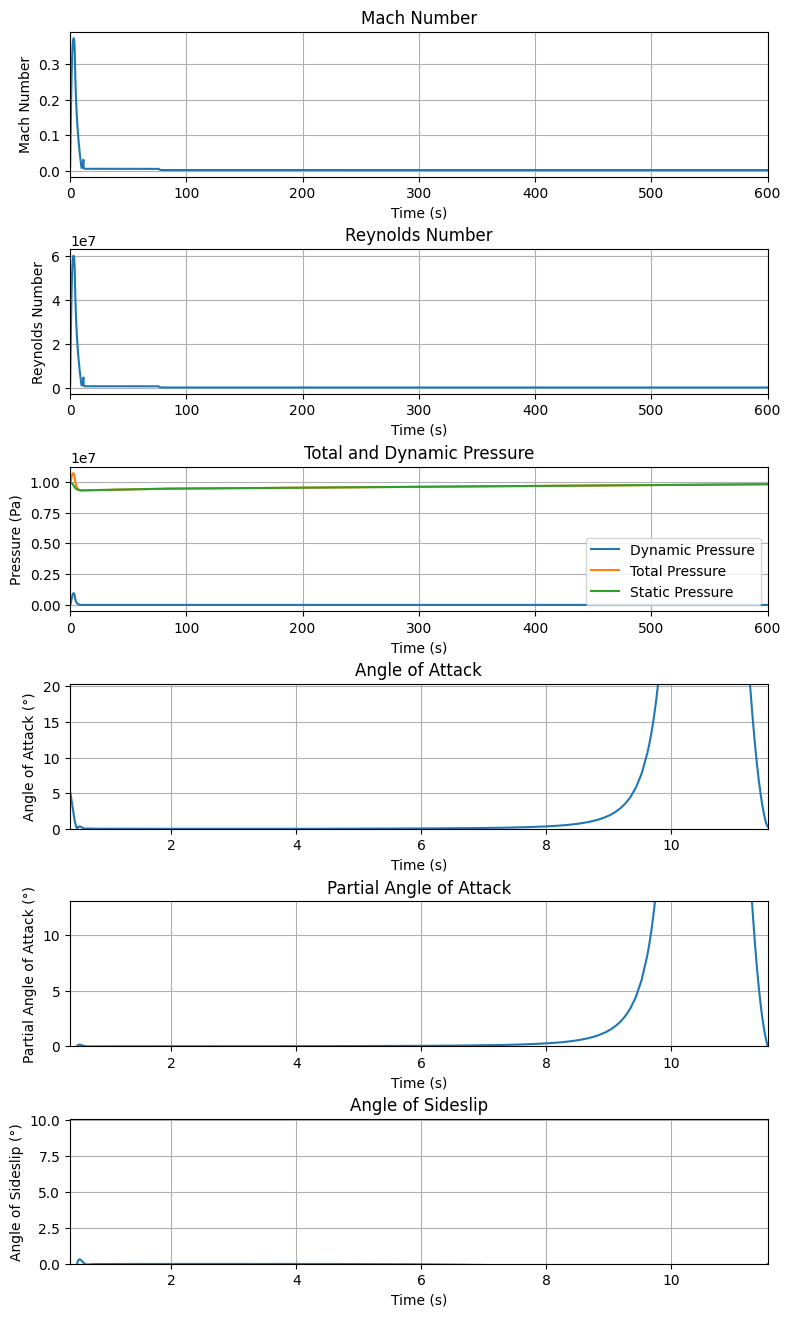



Trajectory Stability and Control Plots



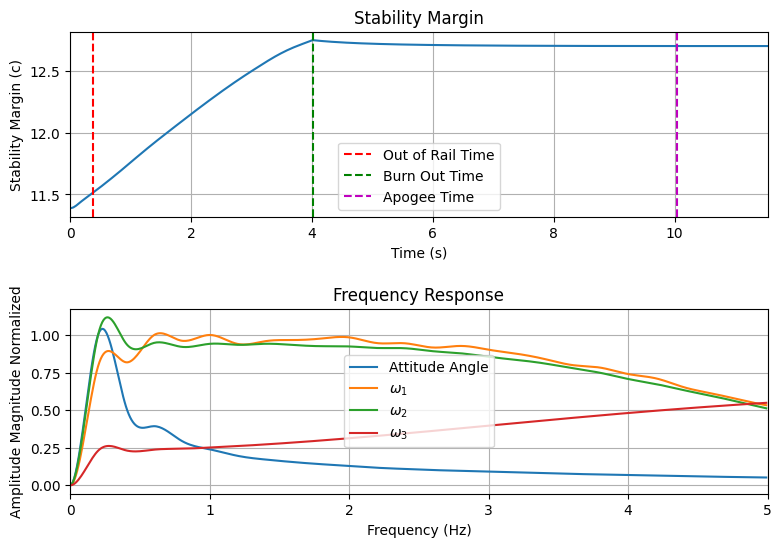



Rocket and Parachute Pressure Plots



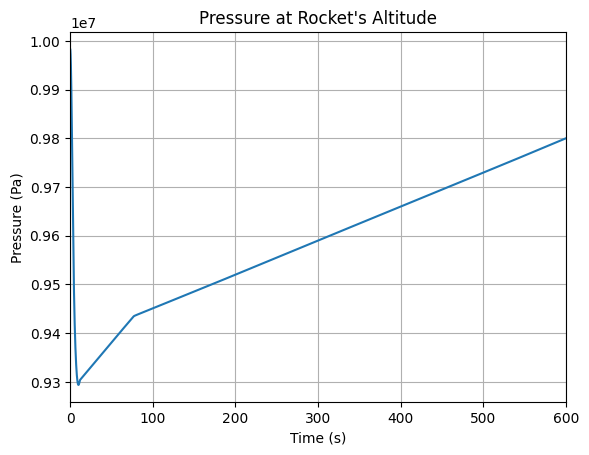


Parachute:  Drogue


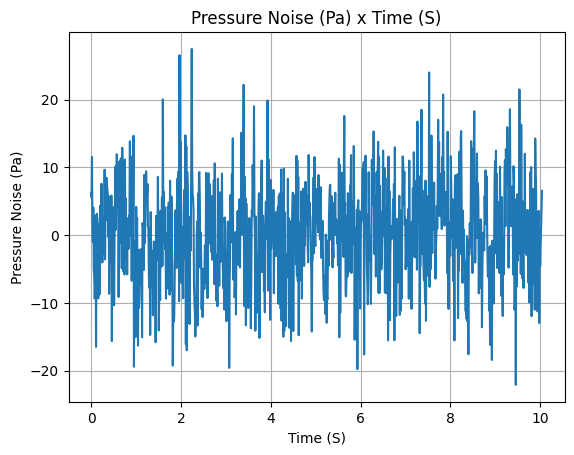

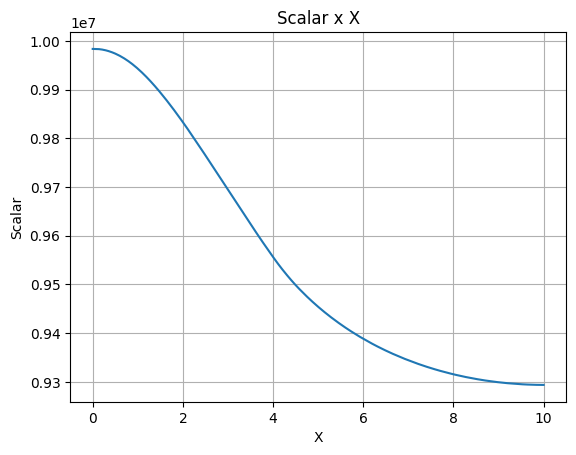

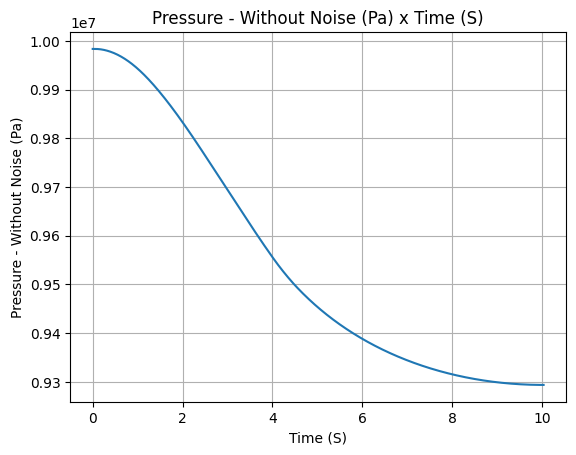


Parachute:  Main


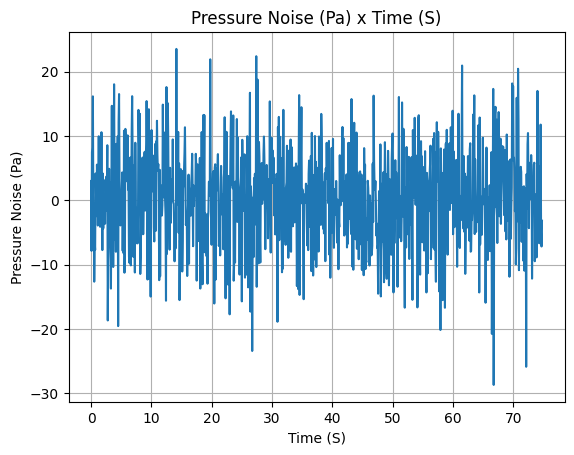

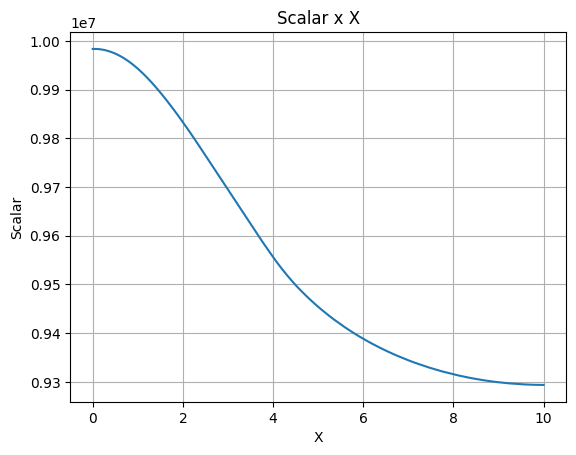

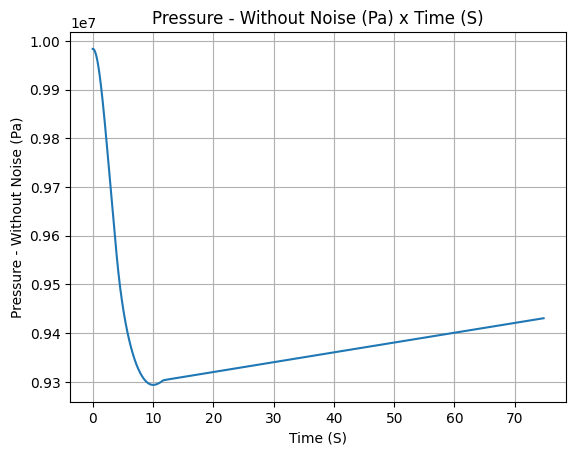

In [ ]:
flight.plots.all()

In [ ]:
# ==============================================================
# SECTION 7 : RESULTS SUMMARY
# ==============================================================

print("="*60)
print("          AEGIS-75 HIGH POWER ROCKET")
print("="*60)

print(f"Rocket Diameter        : 75 mm")
print(f"Rocket Length          : 3.10 m")
print(f"Rocket Empty Mass      : 18.00 kg")
print(f"Motor                  : AeroTech M1850W")
print(f"Launch Rail Length     : 6.0 m")
print(f"Launch Inclination     : 85°")

print()

print(f"Maximum Altitude       : {flight.apogee:.2f} m")
print(f"Total Flight Time      : {flight.t_final:.2f} s")
print(f"Rail Exit Velocity     : {flight.out_of_rail_velocity:.2f} m/s")

print("="*60)

          AEGIS-75 HIGH POWER ROCKET
Rocket Diameter        : 75 mm
Rocket Length          : 3.10 m
Rocket Empty Mass      : 18.00 kg
Motor                  : AeroTech M1850W
Launch Rail Length     : 6.0 m
Launch Inclination     : 85°

Maximum Altitude       : 699.83 m
Total Flight Time      : 600.00 s
Rail Exit Velocity     : 27.36 m/s


In [ ]:
# Export trajectory data

flight.export_data(
    "Aegis75_FlightData.csv"
)

print("Flight data exported successfully.")

Flight data exported successfully.


/tmp/ipykernel_1330/1931020270.py:3: DeprecationWarning: Moved to FlightDataExporter.export_data() and will be removed in v1.12.0. Use `rocketpy.simulation.flight_data_exporter.FlightDataExporter.export_data` instead.
  flight.export_data(


In [ ]:
flight.export_kml(
    file_name="Aegis75Trajectory.kml",
    extrude=True,
    altitude_mode="relative_to_ground",
)

print("KML exported.")

File  Aegis75Trajectory.kml  saved with success!
KML exported.


/tmp/ipykernel_1330/167022388.py:1: DeprecationWarning: Moved to FlightDataExporter.export_kml() and will be removed in v1.12.0. Use `rocketpy.simulation.flight_data_exporter.FlightDataExporter.export_kml` instead.
  flight.export_kml(
